# Recurrent Neural Network


The intention behind this project is to build a **Recurrent Neural Network** that can perform prediction on sine waves. The aim is to implement and develop a comprehensive understanding of core recurrence mechanics such as Backpropagation Through Time (BPTT) and how sequential data affects the training the process. <br>

**Main Objectives**:
- <u>Create Data</u>
- <u>Data Visualization</u>
- <u>Train/Test Split</u>
- <u>Create DataLoaders
- Building the Model
- Creating the Training Loop</u>
- <u>Inference/Predictions</u>

**Extra**:
- <u>Implement a **Recurrent Neural Network** from scratch.
- Non-modular
- Forward pass:
  - Hidden state update and output computation
- **Backpropagation Through Time** (BPTT)
  - Compute gradients for weights and biases over multiple time steps.
  - Clip gradients to prevent exploding gradients.</u>

- <u>Handling initial states, allow passing of initial hidden state $h_0$.
- Activation functions and loss function.</u>

In [229]:
import numpy as np
import pandas
import matplotlib.pyplot as plt
import torch
import sklearn
import torch.nn as nn

## Recurrent Neural Network (RNN) Implementation

**Recurrent Neural Network (RNN)** is a sequential model that processes inputs one timestep at a time, maintaining a **hidden state** that carries information across the sequence.

This implementation is non-modular and consists of an input layer, a recurrent layer, and an output layer. The input is of shape $(batch\_size, seq\_length, num\_features)$.

---

## Forward Propagation

At each timestep $t$, the hidden state and output are computed as:

$$M_t = X_tW_{hx}^T+H_{t-1}W_{hh}^T+b_h$$
$$H_t = \tanh(M_t)$$
$$O_t = H_tW_{qh}^T+b_q$$

where:
- $X_t$ is the input at timestep $t$
- $H_{t-1}$ is the hidden state from the previous timestep
- $W_{hx}, W_{hh}, W_{qh}$ are the input, recurrent, and output weight matrices
- $b_h, b_q$ are the hidden and output biases

The loss is averaged across all $T$ timesteps:

$$L=\frac{1}{T}\sum^T_{t=1}l(O_t, Y_t)$$

---

## Backpropagation Through Time (BPTT)

Gradients are computed by unrolling the network across timesteps and propagating errors backwards:

$$\overline{O}_t=\frac{1}{T}(Y_t-O_t)$$
$$\overline{H}_t=\overline{M}_{t+1}W_{hh}^T + \overline{O}_tW_{qh}$$
$$\overline{M}_t=\overline{H}_t\odot(1-\tanh^2(M_t))$$
$$\overline{X}_t=\overline{M}_tW_{hx}$$

Parameter gradients are accumulated across all timesteps:

$$\overline{W}_{qh}=\sum^T_{t=1}(\overline{O}_t)^TH_t$$
$$\overline{W}_{hh}=\sum^T_{t=1}(\overline{M}_t)^TH_{t-1}$$
$$\overline{W}_{hx}=\sum^T_{t=0}(\overline{M}_t)^TX_t$$
$$\overline{b}_{q}=\sum^T_{t=1}(\overline{O}_t)^T\mathbf{1}$$
$$\overline{b}_{h}=\sum^T_{t=1}(\overline{M}_t)^T\mathbf{1}$$

**Note:** Since the task is prediction, the output layer gradients $\overline{W}_{qh}$ and $\overline{b}_q$ use only the final timestep $T$, with no summation.

---

## Vanishing Gradients

Vanishing gradients occur when gradients shrink exponentially as they are backpropagated through many timesteps, effectively preventing earlier layers from receiving useful updates. As a result, the model fails to learn long-range dependencies and loses information from earlier parts of the sequence.

**Note:** This is a fundamental limitation of vanilla RNNs. Gated architectures such as **LSTMs** and **GRUs** were designed specifically to address this by controlling the flow of gradients through learnable gates.

In [432]:
# Helper Functions - Loss functions, activations, clipping, optimization, etc.
def MSELoss(preds, y):
  """
  Computes the Mean Squared Error (MSE) loss between predictions and targets

  Args:
    y: Predictions of shape (N, 1).
    preds: Targets of shape (N, 1).

  Returns:
    loss: The MSE loss.
  """
  n = y.shape[0]
  return (1 / (2*n)) * np.sum((preds - y) ** 2)

def tanh(X):
  return np.tanh(X)

def tanh_derivative(X):
  return 1 - (np.tanh(X) ** 2)

def norm_gradient_clipping(W_bar, clip_coef=5.0):
  """
  Applies norm clipping to the gradients.

  Args:
    W_bar: a list of gradients.
    clip_coef: Maximum allowed L2 norm for a gradient. If the norm of a gradient
             exceeds this value, it is scaled down to have norm = clip_coef.

  Returns:
    W_bar: the list of clipped gradients
  """
  for i in range(len(W_bar)):
    norm = np.sqrt(np.sum(W_bar[i]**2))
    if norm >= clip_coef:
      grad_clipped = clip_coef * (W_bar[i] / norm)
      W_bar[i] = grad_clipped

  return W_bar

def Adam(W_bar, m_t, v_t, t, beta1=0.9, beta2=0.999):
  """
  Computes Adam first and second moment estimates for a list of gradients.

  Args:
    W_bar: List of gradients for each parameter (same shapes as parameters).
    t: Current time step (iteration number), used for bias correction.
    beta1: Exponential decay rate for the first moment estimates.
    beta2: Exponential decay rate for the second moment estimates.

  Returns:
    vhat_t: List of bias-corrected second moment estimates.
    mhat_t: List of bias-corrected first moment estimates.
  """
  mhat_t = [np.zeros_like(W) for W in W_bar]
  vhat_t = [np.zeros_like(W) for W in W_bar]

  for i in range(len(W_bar)):
    m_t[i] = beta1 * m_t[i] + (1 - beta1) * W_bar[i]
    v_t[i] = beta2 * v_t[i] + (1 - beta2) * (W_bar[i]) ** 2
    mhat_t[i] = m_t[i] / (1 - beta1 ** t)
    vhat_t[i] = v_t[i] / (1 - beta2 ** t)

  return vhat_t, mhat_t, m_t, v_t

def Xavier(fan_in, fan_out):
  """
  Computes the Xavier (Glorot) initialization scale.

  Args:
    fan_in: Number of input units to the layer.
    fan_out: Number of output units from the layer.

  Returns:
    scale: A scalar value used to sample initial weights uniformly from
           the range [-scale, scale], where:
               scale = sqrt(6 / (fan_in + fan_out))
  """
  return np.sqrt(6 / (fan_in + fan_out))

def minibatch_sampling(X, y, batch_size):
  """
  Splits the dataset into mini-batches.

  Args:
    X: Input data of shape (N, seq_len, num_features). N is the number of samples.
    y: Target labels of shape (N, 1).
    batch_size: Number of samples per mini-batch.

  Returns:
    batches: A dictionary where each key maps to a mini-batch, batches[i] = [X_batch, y_batch].
  """
  # Get indices
  indexes = np.arange(0, len(X), step=1)
  n = X.shape[0] # number of samples

  # Randomize indices
  np.random.shuffle(indexes)
  X = X[indexes]
  y = y[indexes]

  n_batches = n // batch_size
  batches = {}

  for i in range(n_batches):
    batches[i] = [X[i*batch_size:(i+1)*batch_size], y[i*batch_size:(i+1)*batch_size]]

  if n % batch_size != 0:
    batches[n_batches] = [X[n_batches*batch_size: ], y[n_batches*batch_size:]]

  return batches


In [433]:
class RecurrentNeuralNetwork():
  """
  This is a manual implementation of a Recurrent Neural Network (RNN) with one input layer, one hidden layer, and an output layer.

  Parameters:
  - input_size: number of input features
  - hidden_size: hidden size of the network
  - output_size: number of output dimensions
  - epochs: the number of epochs for training and validation
  - learning_rate: the learning_rate of the optimizer
  - optim: either set to None (in which case, standard gradient descent) or Adam (use the Adam optimizer)
  - batch_size: the batch size used for training, validation, and evaluation.

  """
  def __init__(self, input_size, hidden_size, output_size, epochs=5, learning_rate=0.001, optim=None, batch_size=48):
    # Hyperparameters
    self.epochs = epochs
    self.alpha = learning_rate
    self.optim = optim
    self.batch_size = batch_size

    # Initialize dimensions
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.output_size = output_size
    self.seq_len = None

    # Weights and biases
    c0 = Xavier(input_size, hidden_size)
    self.w_x = np.random.uniform(low=-c0, high=c0, size=(hidden_size, input_size))

    c1 = Xavier(hidden_size, hidden_size)
    self.w_h = np.random.uniform(low=-c1, high=c1, size=(hidden_size, hidden_size))

    c2 = Xavier(hidden_size, output_size)
    self.w_y = np.random.uniform(low=-c2, high=c2, size=(output_size, hidden_size))

    self.b_x = np.zeros((1, hidden_size))
    self.b_y = np.zeros((1, output_size))

    # Store information
    self.h = []
    self.m = []
    self.o = []

    # Adam time step, m_t, and v_t
    self.t = 0
    self.m_t = [np.zeros_like(W) for W in [self.w_x, self.w_h, self.w_y, self.b_x, self.b_y]]
    self.v_t = [np.zeros_like(W) for W in [self.w_x, self.w_h, self.w_y, self.b_x, self.b_y]]

    # Metrics
    self.training_loss = []
    self.val_loss = []

    # Mode
    self.mode = None

  def train(self, X, y, X_val, y_val):
    """
    A full training and validation pipeline for the RNN

    Args:
      X: Input data for training of shape (N, seq_len, num_features).
      y: Input data for training of shape (N, 1).
      X_val: Input data for validation of shape (N, seq_len, num_features).
      y_val: Input data for validation of shape (N, 1).

    Returns:
      None
    """
    self.seq_len = X.shape[1]

    for i in range(self.epochs):
      # Get batches
      train_batches = minibatch_sampling(X, y, self.batch_size)
      val_batches = minibatch_sampling(X_val, y_val, self.batch_size)

      # Set metrics
      train_loss = 0
      val_loss = 0

      # Loop through Training Data
      self.mode = "train"
      for X_batch, y_batch in train_batches.values():

        # Get predictions
        X_batch = X_batch.transpose(1, 0, 2)
        y_batch = np.expand_dims(y_batch, axis=1)
        preds = self.forward(X_batch)

        # Calculate loss
        loss = MSELoss(preds, y_batch)

        # Backpropagation Through Time (BPTT)
        W_bar = self.backpropagation_through_time(X_batch, y_batch, preds)

        # Norm Clipping
        W_bar_clipped = norm_gradient_clipping(W_bar)

        # Gradient Descent
        if self.optim == "Adam":
          self.t += 1 # change t per state update
          vhat_t, mhat_t, self.m_t, self.v_t = Adam(W_bar_clipped, self.m_t, self.v_t, self.t)
          self.gradient_descent(vhat_t=vhat_t, mhat_t=mhat_t)
        else:
          self.gradient_descent(W_bar=W_bar_clipped)

        # Compute Metrics
        train_loss += loss

      # Loop through Validation Data
      self.mode = "val"
      for X_val_batch, y_val_batch in val_batches.values():
        # Get preds
        X_val_batch = X_val_batch.transpose(1, 0, 2)
        y_val_batch = np.expand_dims(y_val_batch, axis=1)
        preds = self.forward(X_val_batch)

        # Calculate loss
        loss = MSELoss(preds, y_val_batch)

        # Compute metrics
        val_loss += loss

      # Epoch metrics
      train_epoch_loss = train_loss / len(train_batches)
      val_epoch_loss = val_loss / len(val_batches)

      print("The train loss at epoch {0} is {1:.2f}".format(i, train_epoch_loss))
      print("The validation loss at epoch {0} is {1:.2f}".format(i, val_epoch_loss))

      # Append metrics for plots
      self.training_loss.append(train_epoch_loss)
      self.val_loss.append(val_epoch_loss)

  def forward(self, X):
    """
    The forward pass for the RNN, sequence-to-one style.

    Args:
      X: Input data f shape (N, seq_len, num_features).
    Returns:
      o_t: output at the last time step.
    """
    # Input is (seq_len, batch, num_features)
    self.h = []
    self.m = []
    self.o = []

    # Initialize hidden state h0
    if not self.h:
      self.h.append(np.zeros((X.shape[1], self.hidden_size)))

    # Forward pass, compute hidden state and output
    for i in range(self.seq_len):
      m_t = X[i] @ self.w_x.T + self.h[-1] @ self.w_h.T + self.b_x
      h_t = tanh(m_t) # tanh activation function
      o_t = h_t @ self.w_y.T + self.b_y

      if self.mode == "train":
        self.h.append(h_t)
        self.m.append(m_t)
        self.o.append(o_t)

    return o_t # only return output at last time step

  def backpropagation_through_time(self, X, y, preds):
    """
    The backpropagation through time (BPTT) algorithm.

    Args:
      X: Input data of shape (seq_len, N, num_features).
      y: The targets of shape (N, 1)
      preds: The model predictions of shape (N, 1)
    Returns:
      W_bar: the gradients in format (wx_bar, wh_bar, wy_bar, bx_bar, by_bar)
    """
    bx_bar = np.zeros_like(self.b_x)
    by_bar = np.zeros_like(self.b_y)
    wh_bar = np.zeros_like(self.w_h)
    wy_bar = np.zeros_like(self.w_y)
    wx_bar = np.zeros_like(self.w_x)

    for i in reversed(range(self.seq_len)):
      if i == (self.seq_len - 1):
        o_bar = (1 / X.shape[1]) * (preds - y)
        by_bar += np.sum(o_bar, axis=0, keepdims=True)
        h_bar = o_bar @ self.w_y # at time = T
        wy_bar += o_bar.T @ self.h[i+1]
        m_bar = h_bar * tanh_derivative(self.m[i])
        wh_bar +=  m_bar.T @ self.h[i]
      else:
        h_bar = m_bar @ self.w_h
        m_bar = h_bar * tanh_derivative(self.m[i])
        wh_bar +=  m_bar.T @ self.h[i]

      bx_bar += np.sum(m_bar, axis=0, keepdims=True)
      wx_bar += m_bar.T @ X[i]

    return [wx_bar, wh_bar, wy_bar, bx_bar, by_bar]

  def gradient_descent(self, W_bar=None, vhat_t=None, mhat_t=None):
    """
    Gradient descent to update model parameters.

    Args:
      W_bar: Gradients in format (wx_bar, wh_bar, wy_bar, bx_bar, by_bar)
      vhat_t: Bias-corrected first moment estimates of gradients (mean of gradients)
      mhat_t: Bias-corrected second moment estimates of gradients (mean of squared gradients)
    Returns:
      None
    """
    # format is (wx_bar, wh_bar, wy_bar, bx_bar, by_bar)
    if self.optim is None:
      self.w_x = self.w_x - self.alpha * W_bar[0]
      self.w_h = self.w_h - self.alpha * W_bar[1]
      self.w_y = self.w_y - self.alpha * W_bar[2]
      self.b_x = self.b_x - self.alpha * W_bar[3]
      self.b_y = self.b_y  - self.alpha * W_bar[4]
    elif self.optim == "Adam":
      self.w_x = self.w_x - self.alpha * (mhat_t[0] / (np.sqrt(vhat_t[0]) + 1e-08))
      self.w_h = self.w_h - self.alpha * (mhat_t[1] / (np.sqrt(vhat_t[1]) + 1e-08))
      self.w_y = self.w_y - self.alpha * (mhat_t[2] / (np.sqrt(vhat_t[2]) + 1e-08))
      self.b_x = self.b_x - self.alpha * (mhat_t[3] / (np.sqrt(vhat_t[3]) + 1e-08))
      self.b_y = self.b_y - self.alpha * (mhat_t[4] / (np.sqrt(vhat_t[4]) + 1e-08))

  def evaluate(self, X_test, y_test):
    """
    An inference pipeline for the RNN.

    Args:
      X_test: Input data for testing of shape (N, seq_len, num_features).
      y_test: Input data for testing of shape (N, 1).

    Returns:
      None
    """
    # Get batches
    test_batches = minibatch_sampling(X_test, y_test, self.batch_size)

    test_loss = 0

    # Loop through Test Data
    self.mode = "test"
    for X_test_batch, y_test_batch in test_batches.values():
      # Get preds
      X_test_batch = X_test_batch.transpose(1, 0, 2)
      y_test_batch = np.expand_dims(y_test_batch, axis=1)
      preds = self.forward(X_test_batch)

      # Compute loss
      loss = MSELoss(preds, y_test_batch)

      # Calculate metrics
      test_loss += loss

    test_loss = test_loss / len(test_batches)

    print("The test loss is {0:.2f}".format(test_loss))



In [434]:
# Train test split
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(X_train, y_train, test_size=0.2, train_size=0.8, shuffle=False)
X_train_np = X_train_np.detach().numpy()
y_train_np = y_train_np.detach().numpy()
X_val_np = X_val_np.detach().numpy()
y_val_np = y_val_np.detach().numpy()

In [461]:
rnn_implementation = RecurrentNeuralNetwork(input_size=1, hidden_size=64, output_size=1, epochs=10)

In [462]:
rnn_implementation.train(X_train_np, y_train_np, X_val_np, y_val_np)

The train loss at epoch 0 is 0.06
The validation loss at epoch 0 is 0.10
The train loss at epoch 1 is 0.02
The validation loss at epoch 1 is 0.08
The train loss at epoch 2 is 0.01
The validation loss at epoch 2 is 0.08
The train loss at epoch 3 is 0.00
The validation loss at epoch 3 is 0.08
The train loss at epoch 4 is 0.00
The validation loss at epoch 4 is 0.08
The train loss at epoch 5 is 0.00
The validation loss at epoch 5 is 0.08
The train loss at epoch 6 is 0.00
The validation loss at epoch 6 is 0.09
The train loss at epoch 7 is 0.00
The validation loss at epoch 7 is 0.08
The train loss at epoch 8 is 0.00
The validation loss at epoch 8 is 0.08
The train loss at epoch 9 is 0.00
The validation loss at epoch 9 is 0.09


In [463]:
X_test_np = X_test.detach().numpy()
y_test_np = y_test.detach().numpy()
rnn_implementation.evaluate(X_test_np, y_test_np)

The test loss is 0.19


## Create Dataset

In [129]:
t = np.linspace(0, 4 * np.pi, 1000)
y = np.sin(t)

In [130]:
def create_sequences(y, window_size=50):
  X = []
  Y = []
  for i in range(len(y) - window_size):
    X.append(y[i:i+window_size])
    Y.append(y[i + window_size])

  return np.array(X), np.array(Y)

data, labels = create_sequences(y)

## Data Visualization and Train/Test split

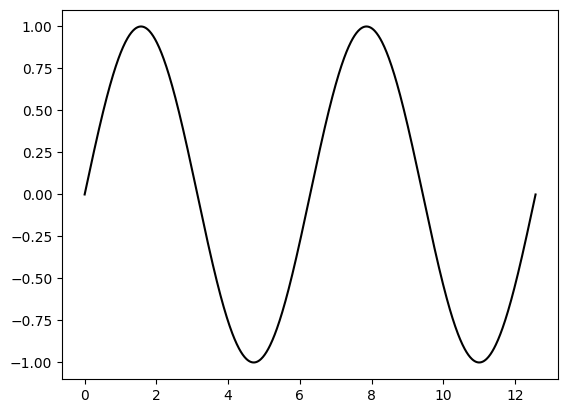

In [131]:
plt.plot(t, y, c='black')
plt.show()

In [132]:
from sklearn.model_selection import train_test_split

# Train test split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, train_size=0.8, shuffle=False)

# As RNN expects (batch, seq_len, num_features), add feature dimension.
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

X_train.shape, X_test.shape

((760, 50, 1), (190, 50, 1))

## Create DataLoaders and Build the Model

In [133]:
from torch.utils.data import DataLoader, TensorDataset

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Torch datasets
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Torch dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [134]:
# Build the RNN model
class RNN(nn.Module):
  def __init__(self, input_size, output_size, hidden_size):
    super(RNN, self).__init__()
    self.rnn = nn.RNN(input_size, hidden_size)
    self.h2o = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    out, hidden = self.rnn(x)
    output = self.h2o(out[-1])

    return output

## Training Loop

In [413]:
def train(rnn, training_data, n_epochs=5, n_batch_size=64, report_every=50, learning_rate=0.001, criterion=nn.MSELoss()):
  """
  Learn on a batch of training data for a specified number of iterations and reporting thresholds
  """
  # Losses for plotting
  current_loss = 0
  total_samples = 0
  all_losses = []
  rnn.train()
  optimizer = torch.optim.Adam(rnn.parameters(), lr=learning_rate)

  print(f"Training on a dataset with n = {len(training_data)}")
  for i in range(n_epochs):
    loss_tracking = 0

    for batch in training_data:
      # Get X and y for batch
      X_train_batch, y_train_batch = batch

      # to match expected shape
      X_train_batch = X_train_batch.permute(1, 0, 2)
      y_train_batch = y_train_batch.unsqueeze(1)

      # Get batch size
      total_samples += y_train_batch.size(0)

      # Predictions
      preds = rnn(X_train_batch)

      # MSE Loss
      loss = criterion(preds, y_train_batch)

      # Backpropagation
      loss.backward()

      # Gradient descent step
      nn.utils.clip_grad_norm_(rnn.parameters(), 3) # gradient clipping
      optimizer.step()
      optimizer.zero_grad()

      loss_tracking += loss

    epoch_loss = loss_tracking / len(training_data)
    all_losses.append(epoch_loss.item())
    print("The loss at epoch {0} is: {1:.2f}".format(i, all_losses[-1]))

  return all_losses



In [414]:
rnn = RNN(1, 1, 64)
losses = train(rnn, train_dataloader)

Training on a dataset with n = 24
The loss at epoch 0 is: 0.43
The loss at epoch 1 is: 0.03
The loss at epoch 2 is: 0.01
The loss at epoch 3 is: 0.01
The loss at epoch 4 is: 0.01


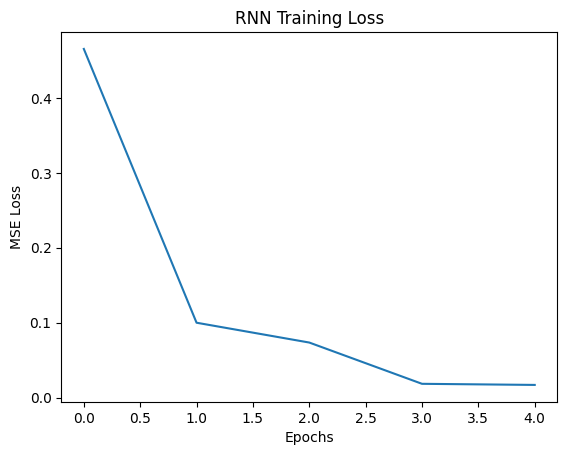

In [137]:
plt.plot(losses)
plt.title("RNN Training Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()

## Evaluation

In [417]:
def evaluate(rnn, testing_data, n_batch_size=64, report_every=50, criterion=nn.MSELoss()):
  """
  Learn on a batch of test data to evaluate model performance.
  """
  # Losses for plotting
  current_loss = 0
  rnn.eval()

  print(f"Testing on a dataset with n = {len(testing_data)}")
  loss_tracking = 0
  total_samples = 0

  with torch.no_grad():
    for batch in testing_data:
      # Get X and y for batch
      X_test_batch, y_test_batch = batch

      # to match expected shape
      X_test_batch = X_test_batch.permute(1, 0, 2)
      y_test_batch = y_test_batch.unsqueeze(1)

      # Predictions
      preds = rnn(X_test_batch)

      # MSE Loss
      loss = criterion(preds, y_test_batch)

      loss_tracking += loss.item()
      total_samples += y_test_batch.size(0)

  test_loss = loss_tracking / len(testing_data)
  print("The test loss is: {0:.2f}".format(test_loss))

  return test_loss



In [418]:
test_loss = evaluate(rnn, test_dataloader)

Testing on a dataset with n = 6
The test loss is: 0.01
